## 1) 设定环境并读取基本信息
解析 `dataset_info.json` 以动态获取数据特征（通道数、采样点、类别等），消除硬编码。

In [28]:
import json
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import copy
from torch.utils.data import DataLoader

# 假设自定义的 Dataset 路径已正确配置
from course_project.TEST_DATASET import TrainDataset, TestDataset

DATA_NAME = "SEED"
DATA_INFO_PATH = f"course_project/{DATA_NAME}/dataset_info.json"
INDEX_PATH_TRAIN = f"course_project/{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"course_project/{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"course_project/{DATA_NAME}/test_x_only.h5"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

num_labels = info["dataset"]["num_labels"]
category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Information ===")
print("Number of Labels:", num_labels)
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

# 动态确定输入特征维度
time_points = int(target_sampling_rate * window_sec)
num_channels = len(channels)
num_classes = num_labels

=== Dataset Information ===
Number of Labels: 3
Categories: ['negative', 'neutral', 'positive']
Channels (count): 62
Target Sampling Rate (Hz): 200.0
Window Size (sec): 2.0


## 2) 检查数据形状

In [29]:
print("========== 检查训练集 (Train) ==========")
with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    
print("\n========== 检查验证集 (Validation) ==========")
with h5py.File(INDEX_PATH_VAL, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    
print("\n========== 检查测试集 (Test - X only) ==========")
with h5py.File(INDEX_PATH_TEST, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)

========== 检查训练集 (Train) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (900, 62, 400)
y dtype: int64
y shape: (900,)
unique: [0 1 2]

========== 检查验证集 (Validation) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (450, 62, 400)
y dtype: int64
y shape: (450,)
unique: [0 1 2]

========== 检查测试集 (Test - X only) ==========
keys: ['X']
x dtype: float32
x shape: (450, 62, 400)


## 3) 定义模型
这里预留了模型替换的空间。

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BalancedGraphConv(nn.Module):
    """
    平衡版动态图卷积层：适度正则化，保留空间拓扑
    """
    def __init__(self, in_features, out_features, num_nodes, drop_edge_rate=0.1):
        super(BalancedGraphConv, self).__init__()
        self.W = nn.Linear(in_features, out_features)
        
        # 单位阵 + 微小噪声初始化 (保证训练初期稳定)
        init_A = torch.eye(num_nodes) + torch.randn(num_nodes, num_nodes) * 0.01
        self.A = nn.Parameter(init_A)
        self.norm = nn.LayerNorm(out_features)
        self.drop_edge_rate = drop_edge_rate

    def forward(self, x):
        adj = F.relu(self.A)
        
        # 节点度归一化
        deg = adj.sum(dim=-1, keepdim=True) + 1e-6
        adj = adj / deg 
        
        # 轻度 DropEdge 扰动 (0.1)
        if self.training and self.drop_edge_rate > 0:
            adj = F.dropout(adj, p=self.drop_edge_rate, training=self.training)
            
        # 空间特征聚合
        out = torch.einsum('vw, bwc -> bvc', adj, x)
        
        out = self.W(out)
        out = self.norm(out)
        return F.gelu(out)


class DGCNN(nn.Module):
    """
    黄金平衡版 DGCNN：找回空间分辨率，精准控参
    """
    def __init__(self, input_channels=62, time_points=400, num_classes=3):
        super(DGCNN, self).__init__()
        self.num_nodes = input_channels
        
        # ==========================================
        # 模块 1: 时序特征提取器 (降低 Dropout 负担)
        # ==========================================
        self.frontend = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=25, padding=12, bias=False),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.MaxPool1d(4),  # 400 -> 100
            
            # 【下调空间失活率，防止信号被过度破坏】
            nn.Dropout1d(p=0.1), 
            
            nn.Conv1d(16, 32, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(4)  # 压缩到长度 4
        )
        
        self.d_in = 32 * 4  # 128
        
        # ==========================================
        # 模块 2: 图卷积模块 (控制输出维度形成瓶颈)
        # ==========================================
        self.gcn1 = BalancedGraphConv(self.d_in, 32, self.num_nodes, drop_edge_rate=0.1)
        # 【关键：极大地压缩每个电极的特征，形成 Information Bottleneck】
        self.gcn2 = BalancedGraphConv(32, 16, self.num_nodes, drop_edge_rate=0.1)
        
        # ==========================================
        # 模块 3: 展平与分类器 (恢复空间拓扑结构)
        # ==========================================
        # 展平维度：62 个电极 * 16 维 = 992 (相比最初的3968，参数量下降了75%，但保留了电极空间独立性)
        self.flatten_dim = self.num_nodes * 16 
        
        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            # 【下调分类器 Dropout】
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, N, T = x.shape
        
        # 1. 提取时间特征
        x = x.view(B * N, 1, T)        
        features = self.frontend(x)    
        features = features.view(B, N, -1)  # (B, 62, 128)
        
        # 2. 图卷积
        g_out = self.gcn1(features)         # (B, 62, 32)
        g_out = self.gcn2(g_out)            # (B, 62, 16)
        
        # 3. 恢复展平 (绝不能再用 mean 消除电极维度！)
        g_out = g_out.reshape(B, -1)        # 保持空间拓扑，形状: (B, 992)
        
        # 4. 情绪分类
        logits = self.classifier(g_out)     # (B, 3)
        
        return logits

## 4) 配置数据加载器、设备与优化器
添加了设备自适应检测（CUDA GPU / Apple MPS / CPU），并优化了超参数区域。

In [35]:
# -------------------------
# 超参数设定
# -------------------------
BATCH_SIZE = 128
EPOCHS = 50          # 增加总 Epoch 数，依靠早停来控制结束
LR = 1e-4
PATIENCE = 10        # 早停的耐心值（验证集持续多少轮不上升则停止）

# -------------------------
# 设定计算设备 (GPU / MPS / CPU)
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# -------------------------
# 准备 DataLoader
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)   
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 实例化模型、损失函数、优化器
# -------------------------
model = DGCNN(input_channels=num_channels, time_points=time_points, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4) # 增加轻度 L2 正则化缓解过拟合

Using device: cpu


## 5) 模型训练与验证
实现了 **Early Stopping** 和 **Best Model 保存机制**。避免模型训练到最后已经严重过拟合。

In [37]:
# 用于记录曲线的数组
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

best_val_acc = 0.0
best_model_weights = None
epochs_no_improve = 0
has_saved_model = False
best_model_path = None 

os.makedirs("model_checkpoints", exist_ok=True)

for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_correct = 0  
    train_num = 0

    for data, label in train_loader:
        data, label = data.to(device), label.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        train_pred = torch.argmax(output, dim=1)
        train_correct += (train_pred == label).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num  
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)     

    # ===== Validation =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data, val_label = val_data.to(device), val_label.to(device)
            
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # 打印每轮训练结果
    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2%} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.2%}"
    )

    # ===== 早停与最佳模型保存逻辑 =====
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        epochs_no_improve = 0  # 只要准确率刷新就重置耐心值
        
        # 从第 10 个 epoch 开始，并且超越了历史最佳才实际保存模型
        if epoch + 1 >= 10:
            best_model_weights = copy.deepcopy(model.state_dict())
            # 为文件加上 Val Accuracy 的值作为后缀
            current_model_path = f"model_checkpoints/{DATA_NAME}_best_model_acc{best_val_acc * 100:.2f}.pth"
  
            # 先将删除旧权重，再更新模型路径并保存
            if best_model_path and os.path.exists(best_model_path):
                os.remove(best_model_path)
            best_model_path = current_model_path
            torch.save(best_model_weights, best_model_path)
            has_saved_model = True
            print(f" ---> 出现更高的验证集准确率 ({best_val_acc:.2%})，已更新模型。")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nTriggered Early Stopping at Epoch {epoch+1}!")
            break
            
    if epoch + 1 == 10:
        print(f" ---> 前 10 个 Epoch 结束，目前的最佳验证集准确率为 {best_val_acc:.2%}")

print("\n" + "-" * 40)
print(f"Final Best Val Accuracy: {best_val_acc:.2%}")

# 最终的结果打印判定
if has_saved_model:
    print(f"训练成功结束！最佳模型已保存至: {best_model_path}")
else:
    print("\n【提醒】训练结束但未保存模型！因为在第 10 个 Epoch 之后，准确率没有超越过前期，请调整代码。")

Epoch [01/50] | Train Loss: 0.9907 | Train Acc: 50.00% | Val Loss: 1.1159 | Val Acc: 36.44%
Epoch [02/50] | Train Loss: 0.9703 | Train Acc: 51.22% | Val Loss: 1.1127 | Val Acc: 37.11%
Epoch [03/50] | Train Loss: 0.9926 | Train Acc: 50.67% | Val Loss: 1.1168 | Val Acc: 38.67%
Epoch [04/50] | Train Loss: 0.9901 | Train Acc: 49.78% | Val Loss: 1.1205 | Val Acc: 39.78%
Epoch [05/50] | Train Loss: 0.9826 | Train Acc: 50.89% | Val Loss: 1.1219 | Val Acc: 38.67%
Epoch [06/50] | Train Loss: 0.9902 | Train Acc: 48.67% | Val Loss: 1.1218 | Val Acc: 38.89%
Epoch [07/50] | Train Loss: 0.9691 | Train Acc: 51.56% | Val Loss: 1.1166 | Val Acc: 37.78%
Epoch [08/50] | Train Loss: 0.9533 | Train Acc: 51.56% | Val Loss: 1.1130 | Val Acc: 38.89%
Epoch [09/50] | Train Loss: 0.9589 | Train Acc: 53.67% | Val Loss: 1.1154 | Val Acc: 38.67%
Epoch [10/50] | Train Loss: 0.9706 | Train Acc: 52.89% | Val Loss: 1.1261 | Val Acc: 38.44%
 ---> 前 10 个 Epoch 结束，目前的最佳验证集准确率为 39.78%
Epoch [11/50] | Train Loss: 0.9409 | T

## 6) 训练过程可视化

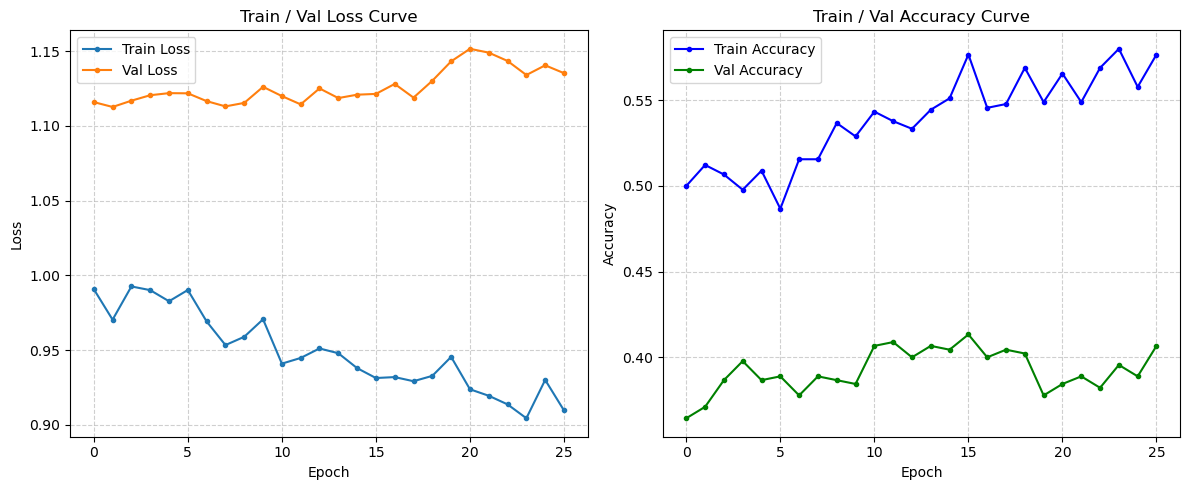

In [38]:
plt.figure(figsize=(12, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker='o', markersize=3)
plt.plot(val_losses, label="Val Loss", marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", marker='o', markersize=3, color='blue')
plt.plot(val_accuracies, label="Val Accuracy", marker='o', markersize=3, color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Val Accuracy Curve") 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## 7) 测试集推理与结果生成
执行测试推理前，将回载上面跑出来的“最佳验证集权重”，以此来产出最终提交的结果。

In [ ]:
# -------------------------
# 加载最佳模型权重
# -------------------------
print(f"Loading best model from {best_model_path} for testing...")
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

output_path = f'course_project/{DATA_NAME}/{DATA_NAME}.txt'
all_test_labels = []

with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_data = test_data.to(device)
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

# 保存 test 预测标签（每行一个数字）
with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")